In [18]:
# ── Core scientific computing libraries ──────────────────────────────────────
import numpy as np                    # Numerical operations (arrays, math)
import pandas as pd                   # Data manipulation and DataFrames
import matplotlib.pyplot as plt       # Plotting and visualization
import seaborn as sns                 # Statistical visualization (heatmaps etc.)

# ── Scikit-learn: data preparation & evaluation ───────────────────────────────
from sklearn.datasets import make_classification   # Generate dummy classification data
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler   # Feature scaling (zero mean, unit var)
from sklearn.metrics import (
    confusion_matrix,          # Shows TP, TN, FP, FN
    classification_report,     # Precision, Recall, F1-Score
    roc_curve,                 # Receiver Operating Characteristic curve
    auc,                       # Area Under the Curve
    accuracy_score             # Overall accuracy
)

# ── TensorFlow / Keras: deep learning framework ──────────────────────────────
import tensorflow as tf                       # Core TensorFlow
from tensorflow.keras.models import Sequential  # Linear stack of layers
from tensorflow.keras.layers import Dense, Dropout  # Fully connected + regularization layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Training helpers
from tensorflow.keras.optimizers import Adam  # Adaptive Moment Estimation optimizer

# ── Reproducibility: fix random seeds so results are the same every run ──────
np.random.seed(42)         # NumPy random seed
tf.random.set_seed(42)     # TensorFlow random seed

# ── Style settings for nicer plots ───────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white grid background
sns.set_palette('husl')                   # Color palette for seaborn plots

print(f"TensorFlow version : {tf.__version__}")
print("All libraries imported successfully! ✅")

TensorFlow version : 2.20.0
All libraries imported successfully! ✅


In [19]:
# ── Generate synthetic classification data ────────────────────────────────────
# make_classification creates a dataset with controllable complexity
X_raw, y = make_classification(
    n_samples=5000,         # Total number of data points (rows)
    n_features=10,          # Number of input features (columns)
    n_informative=7,        # Features that are actually useful for prediction
    n_redundant=2,          # Features that are linear combos of informative ones
    n_repeated=0,           # No repeated/duplicate features
    n_classes=2,            # Binary output: 0 (stay) or 1 (churn)
    class_sep=0.8,          # How well-separated the two classes are (higher = easier)
    flip_y=0.05,            # 5% label noise (simulates real-world imperfection)
    random_state=42         # Reproducibility
)

# ── Wrap in a DataFrame with meaningful column names ──────────────────────────
feature_names = [
    'age', 'tenure', 'monthly_charges', 'total_charges',
    'num_products', 'has_internet', 'support_calls',
    'satisfaction', 'usage_gb', 'contract_len'
]

df = pd.DataFrame(X_raw, columns=feature_names)  # Features DataFrame
df['churn'] = y                                   # Add target column

# ── Quick data inspection ─────────────────────────────────────────────────────
print("Dataset shape:", df.shape)                  # (rows, columns)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df['churn'].value_counts())                  # Check class balance
print(f"\nClass balance ratio: {df['churn'].mean():.2%} churned")

print("\nBasic statistics:")
display(df.describe().round(2))                    # Mean, std, min, max etc.

Dataset shape: (5000, 11)

First 5 rows:


,age,tenure,monthly_charges,total_charges,num_products,has_internet,support_calls,satisfaction,usage_gb,contract_len,churn
0,-2.911382,-1.778723,7.450348,0.901029,1.255801,-5.428197,5.318247,-2.029606,0.598771,7.021815,0
1,-1.207118,0.359276,2.521378,0.452118,1.075609,-2.526193,3.087671,-1.185013,0.918659,3.562936,0
2,1.180788,2.360869,-3.614660,2.502687,2.107586,-0.741806,-1.897304,1.918409,-0.043938,-1.405857,0
3,-0.862591,0.222855,-4.045278,-0.354079,3.487459,-0.376356,0.393522,2.265488,-0.477779,0.386418,1
4,-0.651577,1.280344,0.102065,0.779847,-1.176100,-0.709464,2.383159,1.285558,1.109450,1.294958,1



Class distribution:
churn
0    2509
1    2491
Name: count, dtype: int64

Class balance ratio: 49.82% churned

Basic statistics:


,age,tenure,monthly_charges,total_charges,num_products,has_internet,support_calls,satisfaction,usage_gb,contract_len,churn
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0
mean,-0.13,0.02,0.95,0.39,0.02,-0.82,0.40,-0.03,0.01,0.40,0.5
std,1.05,1.75,2.70,1.74,1.42,1.38,1.57,1.76,1.01,1.76,0.5
min,-5.45,-6.85,-9.00,-6.41,-4.86,-5.93,-5.05,-5.73,-3.96,-6.85,0.0
25%,-0.80,-1.13,-0.86,-0.68,-0.98,-1.71,-0.64,-1.25,-0.67,-0.82,0.0
50%,-0.10,0.08,0.81,0.44,-0.04,-0.83,0.40,-0.05,-0.00,0.38,0.0
75%,0.56,1.21,2.68,1.54,1.00,0.07,1.44,1.17,0.68,1.60,1.0
max,4.14,5.76,12.22,6.68,5.10,4.68,6.83,6.13,3.78,7.02,1.0


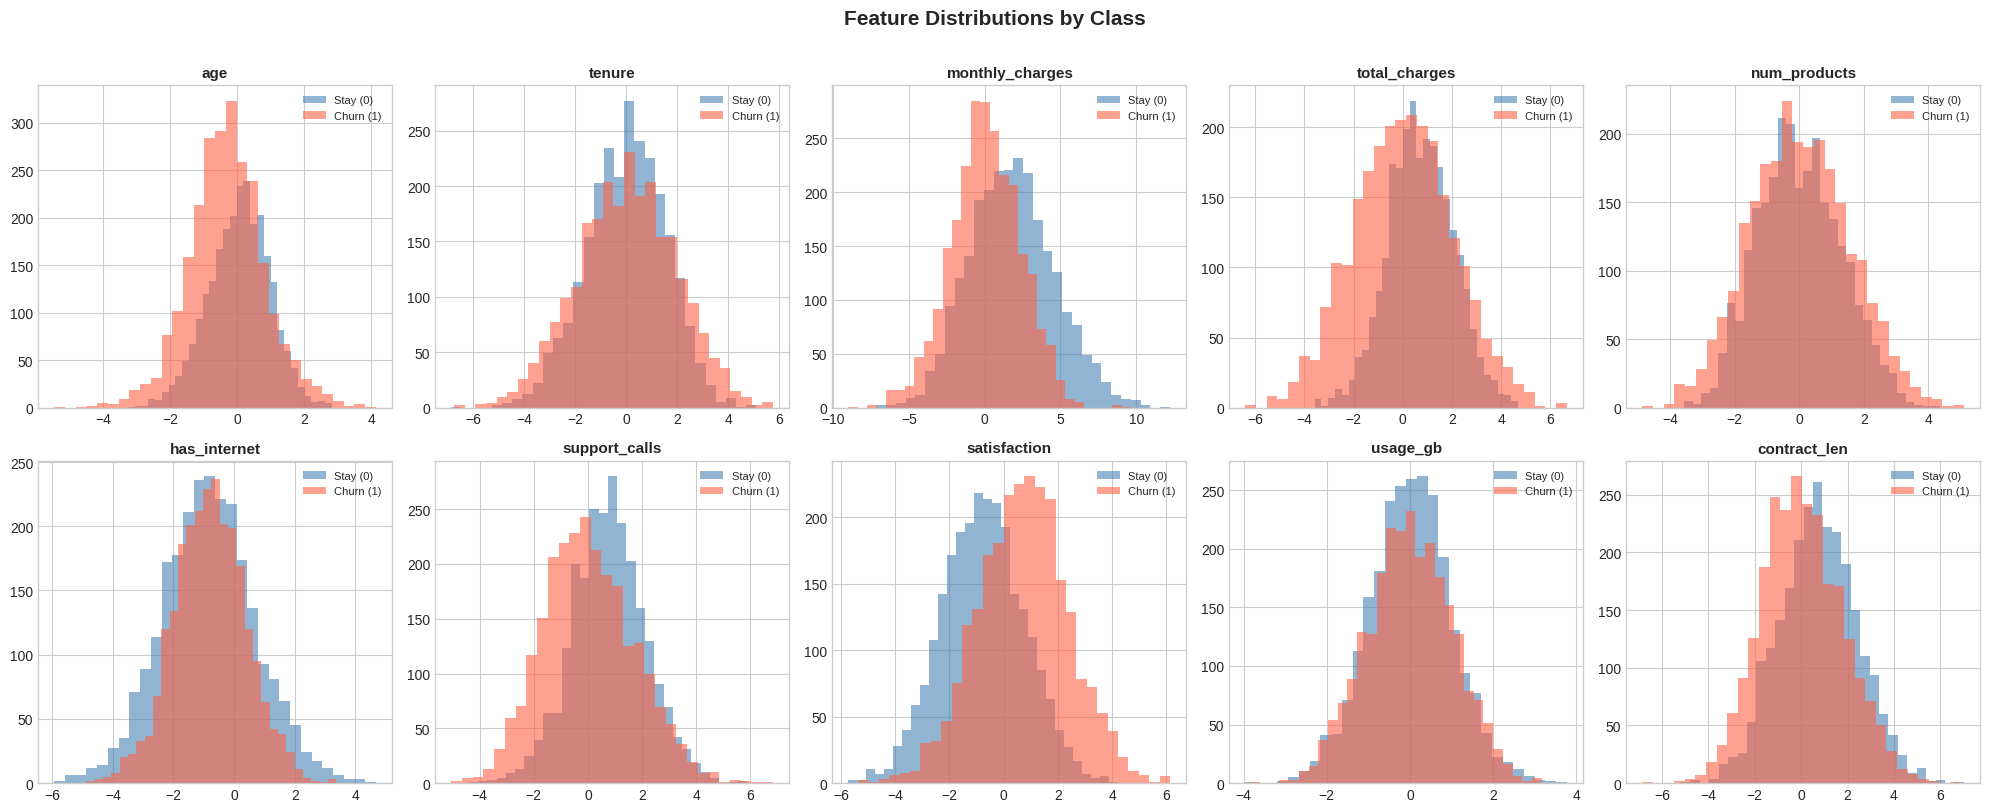

Feature distribution plot saved!


In [20]:
# ── Visualize the raw dataset ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))   # 2 rows × 5 cols grid of plots
axes = axes.flatten()                              # Flatten 2D array → 1D for easy indexing

for i, col in enumerate(feature_names):
    # For each feature, plot distribution separated by class (churn vs stay)
    df[df['churn'] == 0][col].hist(ax=axes[i], alpha=0.6, label='Stay (0)',
                                    color='steelblue', bins=30)
    df[df['churn'] == 1][col].hist(ax=axes[i], alpha=0.6, label='Churn (1)',
                                    color='tomato', bins=30)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature distribution plot saved!")

In [21]:
# ── Separate features (X) and target (y) ─────────────────────────────────────
X = df.drop('churn', axis=1).values   # .values converts DataFrame → NumPy array
y = df['churn'].values                # Target labels as 1D NumPy array

print(f"X shape: {X.shape}")   # (5000, 10) → 5000 samples, 10 features
print(f"y shape: {y.shape}")   # (5000,)    → 5000 labels

# ── Train / Validation / Test split (70% / 15% / 15%) ────────────────────────
# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,       # 30% goes to temp
    random_state=42,      # Fixed seed for reproducibility
    stratify=y            # Keep same class ratio in each split
)

# Step 2: Split temp equally into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,       # Half of 30% → 15%
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain size     : {X_train.shape[0]} samples")
print(f"Validation size: {X_val.shape[0]} samples")
print(f"Test size      : {X_test.shape[0]} samples")

# ── Feature Scaling (Standardization) ────────────────────────────────────────
# Neural networks are sensitive to feature scale.
# StandardScaler transforms features to: mean=0, std=1
# Formula: z = (x - mean) / std

scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data to prevent data leakage
X_train = scaler.fit_transform(X_train)   # Learn mean/std from train, then scale
X_val   = scaler.transform(X_val)         # Apply same learned scaling to val
X_test  = scaler.transform(X_test)        # Apply same learned scaling to test

print("\nAfter scaling — Train feature stats:")
print(f"  Mean  : {X_train.mean(axis=0).round(4)}")  # Should be ~0
print(f"  Std   : {X_train.std(axis=0).round(4)}")   # Should be ~1

X shape: (5000, 10)
y shape: (5000,)

Train size     : 3500 samples
Validation size: 750 samples
Test size      : 750 samples

After scaling — Train feature stats:
  Mean  : [-0. -0. -0. -0. -0. -0.  0. -0. -0.  0.]
  Std   : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [22]:
# ── Build the ANN using Keras Sequential API ──────────────────────────────────
# Sequential = layers are stacked one after another (linear flow)

model = Sequential(name='ANN_Churn_Classifier')

# ── Input + Hidden Layer 1 ────────────────────────────────────────────────────
model.add(Dense(
    units=128,                    # 128 neurons in this layer
    activation='relu',            # ReLU: f(x) = max(0, x) — avoids vanishing gradient
    input_shape=(X_train.shape[1],),  # input_shape = (10,) — 10 features
    kernel_initializer='he_normal',   # He init: suited for ReLU activations
    name='hidden_1'
))
model.add(Dropout(
    rate=0.3,    # Randomly set 30% of neurons to 0 during training
    name='dropout_1'             # Dropout prevents overfitting by adding noise
))

# ── Hidden Layer 2 ────────────────────────────────────────────────────────────
model.add(Dense(
    units=64,
    activation='relu',
    kernel_initializer='he_normal',
    name='hidden_2'
))
model.add(Dropout(rate=0.3, name='dropout_2'))

# ── Hidden Layer 3 ────────────────────────────────────────────────────────────
model.add(Dense(
    units=32,
    activation='relu',
    kernel_initializer='he_normal',
    name='hidden_3'
))
model.add(Dropout(rate=0.2, name='dropout_3'))  # Less dropout in deeper layers

# ── Output Layer ──────────────────────────────────────────────────────────────
model.add(Dense(
    units=1,                      # Single output neuron for binary classification
    activation='sigmoid',         # Sigmoid: outputs probability between 0 and 1
    name='output'                 # P(churn) > 0.5 → predict churn
))

# ── Compile the model ─────────────────────────────────────────────────────────
# This sets the optimizer, loss function, and metrics to track during training
model.compile(
    optimizer=Adam(
        learning_rate=0.001   # Adam: adaptive learning rate optimizer
                              # 0.001 is a safe default starting point
    ),
    loss='binary_crossentropy',  # Loss for binary classification:
                                 # -[y*log(p) + (1-y)*log(1-p)]
    metrics=[
        'accuracy',                                    # (TP+TN) / Total
        tf.keras.metrics.Precision(name='precision'),  # TP / (TP+FP)
        tf.keras.metrics.Recall(name='recall'),        # TP / (TP+FN)
        tf.keras.metrics.AUC(name='auc')               # Area under ROC curve
    ]
)

# ── Print model summary ───────────────────────────────────────────────────────
# Shows layer names, output shapes, and parameter counts
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Churn_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ── Define Callbacks ──────────────────────────────────────────────────────────
# Callbacks are functions that run automatically at certain points during training

# 1. EarlyStopping: stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',     # Watch validation loss
    patience=10,            # Wait 10 epochs before stopping if no improvement
    restore_best_weights=True,  # Restore weights from the best epoch
    verbose=1               # Print message when training stops early
)

# 2. ReduceLROnPlateau: lower learning rate when learning stalls
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Watch validation loss
    factor=0.5,          # Multiply LR by 0.5 when triggered → LR = LR × 0.5
    patience=5,          # Wait 5 epochs before reducing LR
    min_lr=1e-6,         # Don't go below this learning rate
    verbose=1
)

# ── Train the model ───────────────────────────────────────────────────────────
print("Starting training...\n")

history = model.fit(
    X_train, y_train,          # Training features and labels
    epochs=100,                # Maximum number of passes through the full dataset
    batch_size=64,             # Process 64 samples at a time before updating weights
                               # Smaller batch = noisier but faster convergence
    validation_data=(X_val, y_val),  # Data used to evaluate after each epoch
    callbacks=[early_stop, reduce_lr],  # Attach our callbacks
    verbose=1                  # Print progress bar per epoch
)

print(f"\nTraining complete! Ran for {len(history.history['loss'])} epochs.")

Starting training...

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.6097 - auc: 0.6558 - loss: 0.7108 - precision: 0.5987 - recall: 0.6571 - val_accuracy: 0.8320 - val_auc: 0.9062 - val_loss: 0.4663 - val_precision: 0.8464 - val_recall: 0.8102 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7526 - auc: 0.8388 - loss: 0.4981 - precision: 0.7417 - recall: 0.7724 - val_accuracy: 0.8627 - val_auc: 0.9258 - val_loss: 0.3719 - val_precision: 0.8733 - val_recall: 0.8476 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7980 - auc: 0.8778 - loss: 0.4463 - precision: 0.7902 - recall: 0.8096 - val_accuracy: 0.8733 - val_auc: 0.9420 - val_loss: 0.3313 - val_precision: 0.8740 - val_recall: 0.8717 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8237 - auc: 0.8971 - loss: 0.4119 - precision: 0.8150 - recall: 0.8360 - val_accuracy: 0.8747 - val_auc: 0.9436 - va

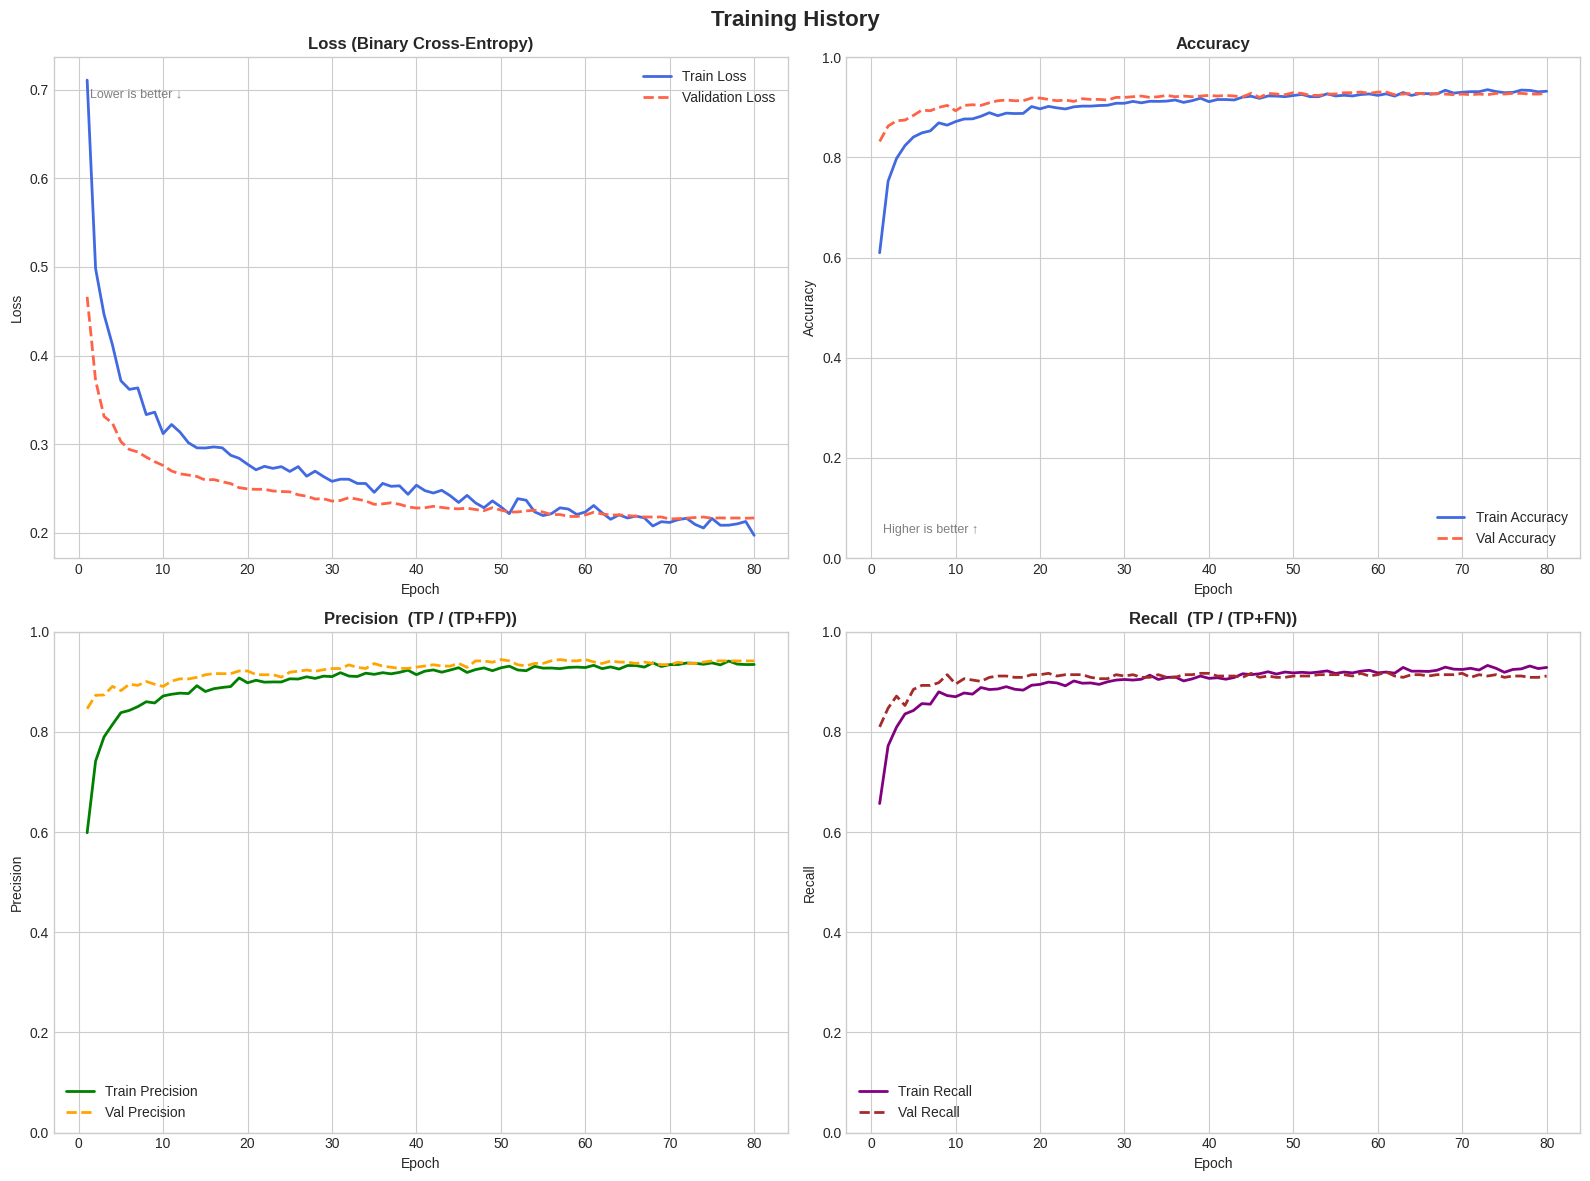

Training history plots saved!


In [24]:
# ── Extract training history data ─────────────────────────────────────────────
# history.history is a dict with keys: 'loss', 'accuracy', 'val_loss', etc.
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)   # X-axis: epoch numbers

# ── Create a 2×2 grid of subplots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# ── Plot 1: Loss (Binary Cross-Entropy) ───────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_ran, hist['loss'],     label='Train Loss',      color='royalblue', lw=2)
ax.plot(epochs_ran, hist['val_loss'], label='Validation Loss', color='tomato',    lw=2, linestyle='--')
ax.set_title('Loss (Binary Cross-Entropy)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
# A large gap between train/val loss = overfitting
ax.annotate('Lower is better ↓', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=9, color='gray')

# ── Plot 2: Accuracy ──────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_ran, hist['accuracy'],     label='Train Accuracy', color='royalblue', lw=2)
ax.plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy',   color='tomato',    lw=2, linestyle='--')
ax.set_title('Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1])
ax.legend()
ax.annotate('Higher is better ↑', xy=(0.05, 0.05), xycoords='axes fraction',
            fontsize=9, color='gray')

# ── Plot 3: Precision ─────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs_ran, hist['precision'],     label='Train Precision', color='green',  lw=2)
ax.plot(epochs_ran, hist['val_precision'], label='Val Precision',   color='orange', lw=2, linestyle='--')
ax.set_title('Precision  (TP / (TP+FP))', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision')
ax.set_ylim([0, 1])
ax.legend()

# ── Plot 4: Recall ────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(epochs_ran, hist['recall'],     label='Train Recall', color='purple', lw=2)
ax.plot(epochs_ran, hist['val_recall'], label='Val Recall',   color='brown',  lw=2, linestyle='--')
ax.set_title('Recall  (TP / (TP+FN))', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall')
ax.set_ylim([0, 1])
ax.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plots saved!")

In [25]:
# ── Get raw probability predictions ──────────────────────────────────────────
# model.predict() returns P(churn=1) for each sample — a float between 0 and 1
y_prob = model.predict(X_test, verbose=0).flatten()   # Shape: (750,)

# ── Convert probabilities → binary class predictions ─────────────────────────
# Standard threshold: 0.5  → if P > 0.5 → predict churn (1)
y_pred = (y_prob >= 0.5).astype(int)                  # Shape: (750,) with 0s and 1s

# ── Compute evaluation metrics ────────────────────────────────────────────────
test_acc  = accuracy_score(y_test, y_pred)             # Overall accuracy
cm        = confusion_matrix(y_test, y_pred)           # [[TN, FP], [FN, TP]]
report    = classification_report(y_test, y_pred,
                target_names=['Stay (0)', 'Churn (1)'])  # Detailed report
fpr, tpr, thresholds = roc_curve(y_test, y_prob)       # ROC curve points
roc_auc   = auc(fpr, tpr)                             # Area Under ROC Curve

# ── Print results ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"           TEST SET EVALUATION RESULTS")
print("=" * 55)
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  ROC-AUC Score  : {roc_auc:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix (raw counts):")
print(cm)
print("  Rows = Actual | Columns = Predicted")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

           TEST SET EVALUATION RESULTS
  Test Accuracy  : 0.9373  (93.73%)
  ROC-AUC Score  : 0.9782

Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.94      0.94      0.94       377
   Churn (1)       0.94      0.94      0.94       373

    accuracy                           0.94       750
   macro avg       0.94      0.94      0.94       750
weighted avg       0.94      0.94      0.94       750


Confusion Matrix (raw counts):
[[353  24]
 [ 23 350]]
  Rows = Actual | Columns = Predicted
  TN=353  FP=24  FN=23  TP=350


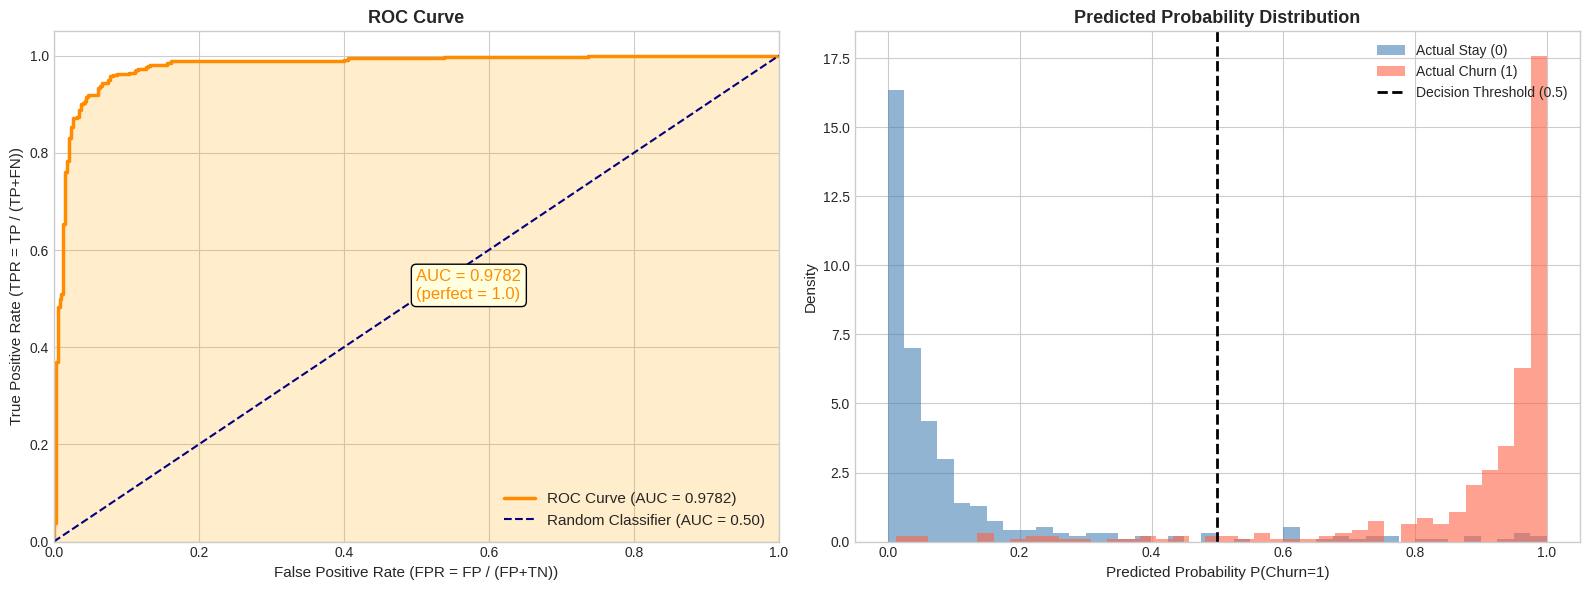

ROC curve saved!


In [27]:
# ============================================================
#  PLOT B: ROC Curve (Receiver Operating Characteristic)
# ============================================================
# ROC curve shows trade-off between True Positive Rate (sensitivity)
# and False Positive Rate (1 - specificity) at various thresholds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: ROC Curve ──────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr,
        color='darkorange', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')   # Main ROC curve
ax.plot([0, 1], [0, 1],
        color='navy', lw=1.5, linestyle='--',
        label='Random Classifier (AUC = 0.50)')       # Baseline: random guessing
ax.fill_between(fpr, tpr, alpha=0.2, color='orange')  # Shade area under curve
ax.set_xlabel('False Positive Rate (FPR = FP / (FP+TN))', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR = TP / (TP+FN))', fontsize=11)
ax.set_title('ROC Curve', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Annotate AUC score
ax.annotate(f'AUC = {roc_auc:.4f}\n(perfect = 1.0)',
            xy=(0.5, 0.5), fontsize=12, color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# ── Right: Probability Distribution ──────────────────────────
# Shows how well the model separates the two classes
ax = axes[1]
ax.hist(y_prob[y_test == 0], bins=40, alpha=0.6,
        color='steelblue', label='Actual Stay (0)', density=True)
ax.hist(y_prob[y_test == 1], bins=40, alpha=0.6,
        color='tomato',    label='Actual Churn (1)', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', lw=2,
           label='Decision Threshold (0.5)')           # Classification boundary
ax.set_xlabel('Predicted Probability P(Churn=1)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Predicted Probability Distribution', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

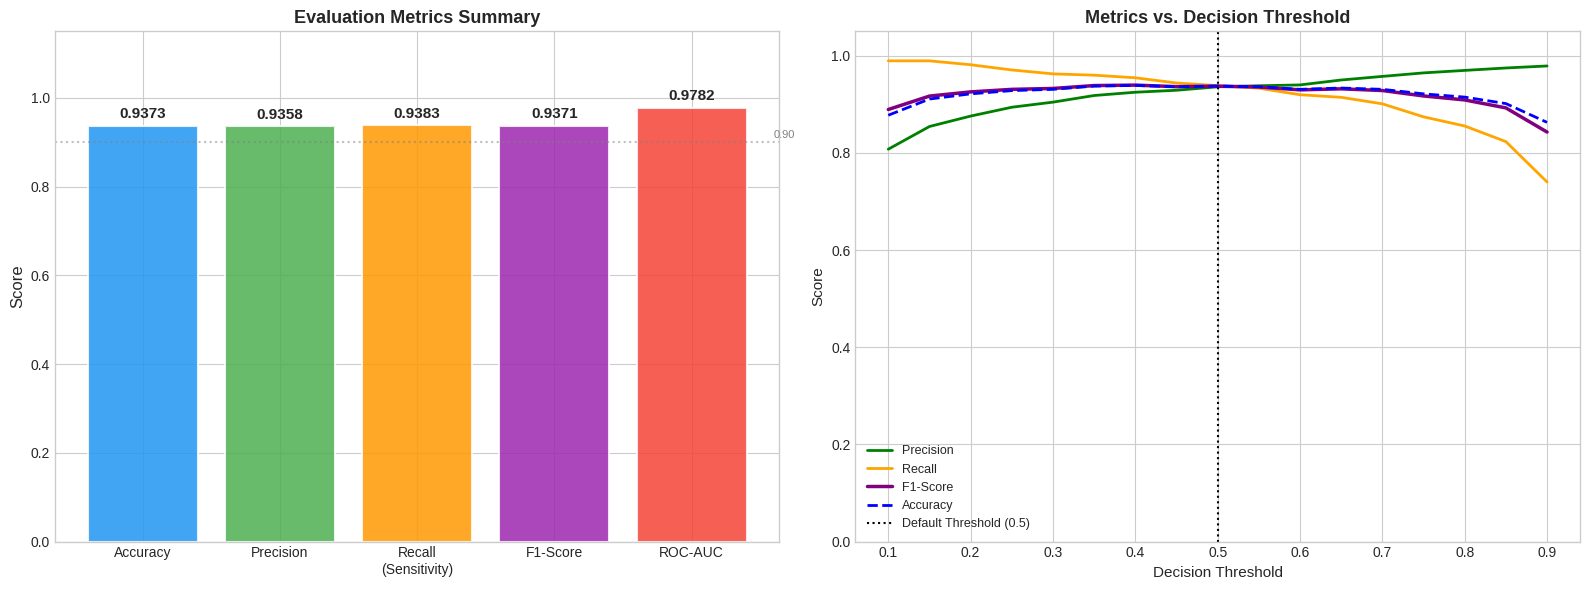

Metrics summary saved!


In [28]:
# ============================================================
#  PLOT C: Metrics Summary Bar Chart + Threshold Analysis
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute individual metric scores
precision = precision_score(y_test, y_pred)   # What fraction of predicted churns are correct?
recall    = recall_score(y_test, y_pred)       # What fraction of actual churns are caught?
f1        = f1_score(y_test, y_pred)           # Harmonic mean of precision & recall

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Metrics Bar Chart ───────────────────────────────────
ax = axes[0]
metric_names  = ['Accuracy', 'Precision', 'Recall\n(Sensitivity)', 'F1-Score', 'ROC-AUC']
metric_values = [test_acc, precision, recall, f1, roc_auc]
colors        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

bars = ax.bar(metric_names, metric_values, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2.0,   # X center of bar
            bar.get_height() + 0.01,                # Slightly above bar top
            f'{val:.4f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_ylim([0, 1.15])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Evaluation Metrics Summary', fontweight='bold', fontsize=13)
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)   # Reference line at 0.9
ax.text(4.6, 0.91, '0.90', fontsize=8, color='gray')

# ── Right: Threshold Analysis ─────────────────────────────────
# How do metrics change as we vary the decision threshold from 0→1?
ax = axes[1]
threshs       = np.arange(0.1, 0.91, 0.05)   # Thresholds to try
t_precisions  = []
t_recalls     = []
t_f1s         = []
t_accs        = []

for t in threshs:
    y_pred_t = (y_prob >= t).astype(int)          # Predict using threshold t
    t_precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    t_recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    t_f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    t_accs.append(accuracy_score(y_test, y_pred_t))

ax.plot(threshs, t_precisions, label='Precision', color='green',  lw=2)
ax.plot(threshs, t_recalls,    label='Recall',    color='orange', lw=2)
ax.plot(threshs, t_f1s,        label='F1-Score',  color='purple', lw=2.5)
ax.plot(threshs, t_accs,       label='Accuracy',  color='blue',   lw=2, linestyle='--')
ax.axvline(x=0.5, color='black', linestyle=':', lw=1.5, label='Default Threshold (0.5)')

ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Metrics vs. Decision Threshold', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Metrics summary saved!")

In [29]:
# ── Create 5 hypothetical new customers ──────────────────────────────────────
# Columns: age, tenure, monthly_charges, total_charges, num_products,
#          has_internet, support_calls, satisfaction, usage_gb, contract_len
new_customers = np.array([
    [ 2.1,  1.5, -0.3,  0.8,  0.5, -1.2,  1.8, -0.7,  0.4,  0.9],  # High risk
    [-1.2,  2.3,  0.1, -0.5, -0.8,  1.1, -0.6,  1.4, -0.9, -1.3],  # Low risk
    [ 0.5, -0.8,  1.2,  0.3,  0.2,  0.4,  0.9, -0.2,  0.6,  0.3],  # Medium risk
    [-0.9,  1.7, -0.7, -0.9,  1.3, -0.3, -1.1,  0.8, -0.4, -0.7],  # Low risk
    [ 1.8,  0.2,  0.9,  1.5, -0.4,  0.7,  1.4, -1.2,  1.1,  1.6],  # High risk
])

# IMPORTANT: Scale new data using the same scaler fitted on training data
# (Already normalized above so we can use directly — in real scenario: scaler.transform(raw))
new_probs = model.predict(new_customers, verbose=0).flatten()
new_preds = (new_probs >= 0.5).astype(int)

# ── Display results ───────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Customer': [f'Customer {i+1}' for i in range(5)],
    'P(Churn)': new_probs.round(4),
    'Prediction': ['🔴 CHURN' if p == 1 else '🟢 STAY' for p in new_preds],
    'Confidence': [f"{max(p, 1-p)*100:.1f}%" for p in new_probs]
})

print("Predictions for New Customers:")
print("=" * 55)
display(results_df.set_index('Customer'))

Predictions for New Customers:


,P(Churn),Prediction,Confidence
Customer,,,
Customer 1,0.1425,🟢 STAY,85.7%
Customer 2,0.7351,🔴 CHURN,73.5%
Customer 3,0.4087,🟢 STAY,59.1%
Customer 4,0.9570,🔴 CHURN,95.7%
Customer 5,0.0719,🟢 STAY,92.8%
